Reading and Opening the file

In [8]:
import pandas as pd
import seaborn as sns

# Load data
df = pd.read_csv('customer_subscription_churn_usage_patterns.csv')

# Show the first 5 rows
print("Setup Successful! Here is your data:")
display(df.head())

Setup Successful! Here is your data:


,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


Converting the "churn" Yes,No to "churn binary(0,1)" i.e; 1 for "yes" and 0 for "no" ,for better understanding of the system to amke the charts. 

In [9]:
# Convert text dates to datetime objects
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Create a binary column for Churn (1 for Yes, 0 for No) 
# This is required for Correlation and Machine Learning
df['churn_binary'] = df['churn'].map({'Yes': 1, 'No': 0})

print("Cleaning complete. Binary churn column added.")

Cleaning complete. Binary churn column added.


Creating figure a two side by side by plan for .
a. first for calculating churn mostly by which plan.
b. second for churn by payment failure issue.

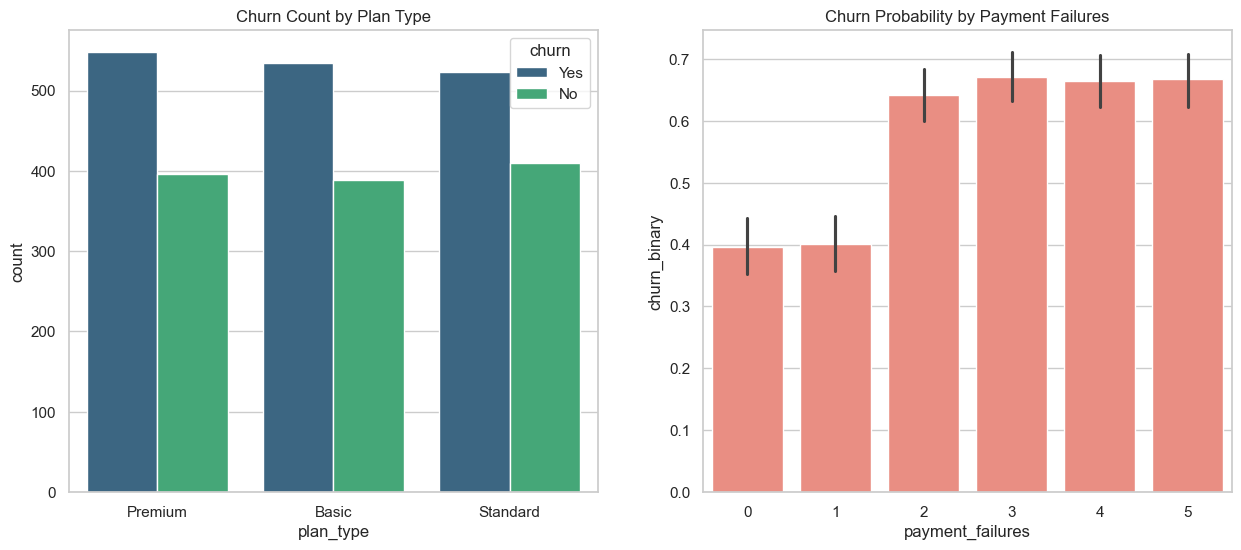

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a 'Figure' with two side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Churn by Plan Type
sns.countplot(data=df, x='plan_type', hue='churn', ax=ax[0], palette='viridis')
ax[0].set_title('Churn Count by Plan Type')

# Plot 2: Payment Failures Impact
sns.barplot(data=df, x='payment_failures', y='churn_binary', ax=ax[1], color='salmon')
ax[1].set_title('Churn Probability by Payment Failures')

plt.show()

make a clear visulaisation  to see See which numbers move together.

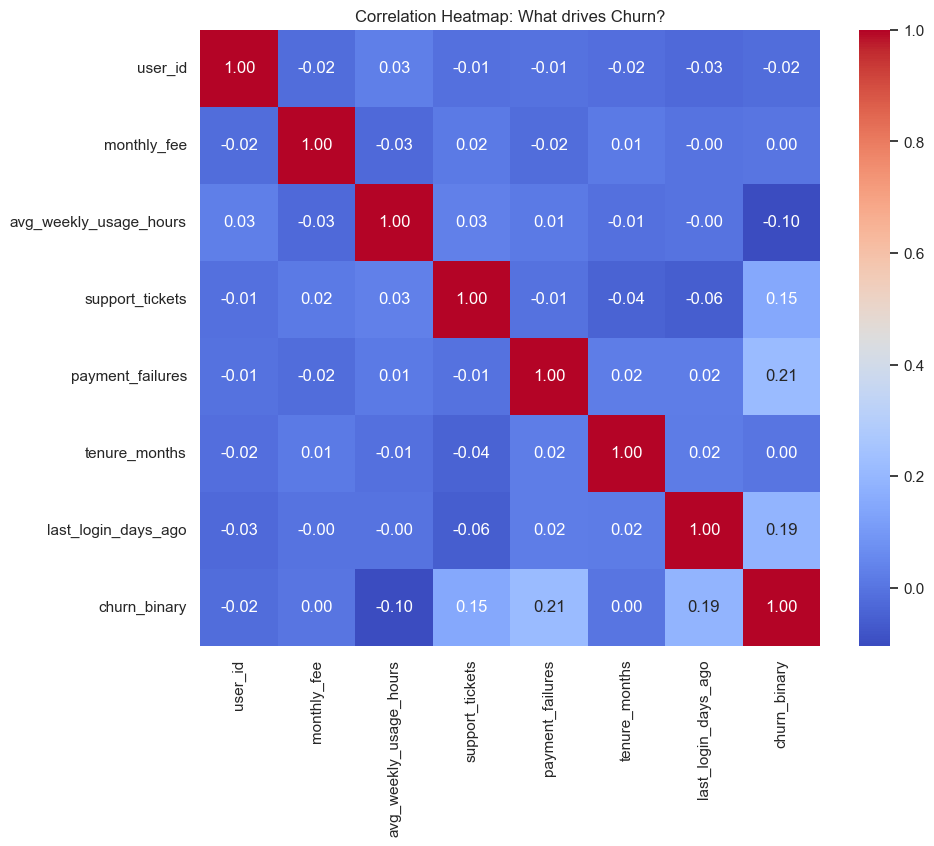

In [11]:
# We only want numeric columns for a heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: What drives Churn?')
plt.show()

teach the computer to predict who will leave next.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define what we are predicting (y) and what we are using to predict (X)
X = df[['monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago']]
y = df['churn_binary']

# Split 80% to learn, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the "Random Forest" model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Show the results
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.55      0.51      0.53       237
           1       0.66      0.70      0.68       323

    accuracy                           0.62       560
   macro avg       0.61      0.61      0.61       560
weighted avg       0.62      0.62      0.62       560

